# 🌍 Projet IDH Afrique — Tableau de bord du Développement Humain

---

| Champ | Valeur |
|---|---|
| **Étudiant** | Frank Laurel |
| **ID Étudiant** | 300143951 |
| **Cours** | Techniques des Systèmes Informatiques (TSI) |
| **Collège** | Collège Boréal — Campus Toronto |
| **Session** | Hiver 2025 |
| **Source de données** | World Bank Open Data API |

---

## 🎯 Objectif du projet

Ce projet analyse les indicateurs de développement humain pour **8 pays d'Afrique subsaharienne** en mettant le **Cameroun** en focus, mon pays d'origine. L'analyse couvre :

- **PIB par habitant** (richesse économique)
- **Espérance de vie** (santé publique)
- **Mortalité infantile** (santé maternelle et infantile)
- **Taux d'alphabétisation** (éducation)
- **Accès à l'électricité** (infrastructure)
- **Accès à Internet** (inclusion numérique)

Les données sont récupérées automatiquement via l'API publique de la Banque Mondiale, analysées avec Python, et visualisées dans ce Notebook.

In [1]:
# ── Imports ─────────────────────────────────────────────────
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Chemins
BASE_DIR   = '/home/ubuntu/300143951'
DATA_DIR   = os.path.join(BASE_DIR, 'data', 'raw')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

print('✅ Imports réussis')
print(f'📂 Données : {DATA_DIR}')
print(f'📊 Output  : {OUTPUT_DIR}')

✅ Imports réussis
📂 Données : /home/ubuntu/300143951/data/raw
📊 Output  : /home/ubuntu/300143951/output


## 📥 Section 1 — Collecte et chargement des données

Les données ont été collectées via le script `scripts/analyse.py` qui appelle l'API World Bank. Chaque indicateur est sauvegardé en **JSON** dans `data/raw/` et en **CSV** pour faciliter l'analyse.

In [2]:
# ── Chargement des données CSV ───────────────────────────────
INDICATORS = {
    'PIB_par_habitant_USD':          'PIB par habitant (USD)',
    'Esperance_de_vie_ans':          'Espérance de vie (ans)',
    'Mortalite_infantile_pour_1000': 'Mortalité infantile (/ 1 000)',
    'Taux_alphabetisation_pct':      "Taux d'alphabétisation (%)",
    'Acces_electricite_pct':         "Accès à l'électricité (%)",
    'Acces_internet_pct':           'Accès à Internet (%)',
}

datasets = {}
for key in INDICATORS:
    csv_path = os.path.join(DATA_DIR, f'{key}.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, index_col='Annee')
        df.index = df.index.astype(str)
        datasets[key] = df
        print(f'✅ {key} — {df.shape[0]} années, {df.shape[1]} pays')
    else:
        print(f'⚠️  Fichier manquant : {csv_path}')
        print('    → Exécuter d abord : bash scripts/analyse.sh')

print(f'\n📊 {len(datasets)} indicateurs chargés.')

✅ PIB_par_habitant_USD — 30 années, 8 pays
✅ Esperance_de_vie_ans — 30 années, 8 pays
✅ Mortalite_infantile_pour_1000 — 30 années, 8 pays
✅ Taux_alphabetisation_pct — 28 années, 8 pays
✅ Acces_electricite_pct — 30 années, 8 pays
✅ Acces_internet_pct — 31 années, 8 pays

📊 6 indicateurs chargés.


## 💰 Section 2 — PIB par habitant

Le **PIB par habitant** mesure la richesse économique moyenne. C'est un indicateur clé du niveau de développement. Un PIB faible indique souvent des infrastructures limitées, un accès réduit aux services publics, et une plus grande vulnérabilité aux crises.

**Contexte Cameroun** : Avec un PIB par habitant modéré pour l'Afrique subsaharienne, le Cameroun fait partie des économies émergentes de la région, mais reste en deçà des grandes puissances africaines comme l'Afrique du Sud ou le Nigeria.

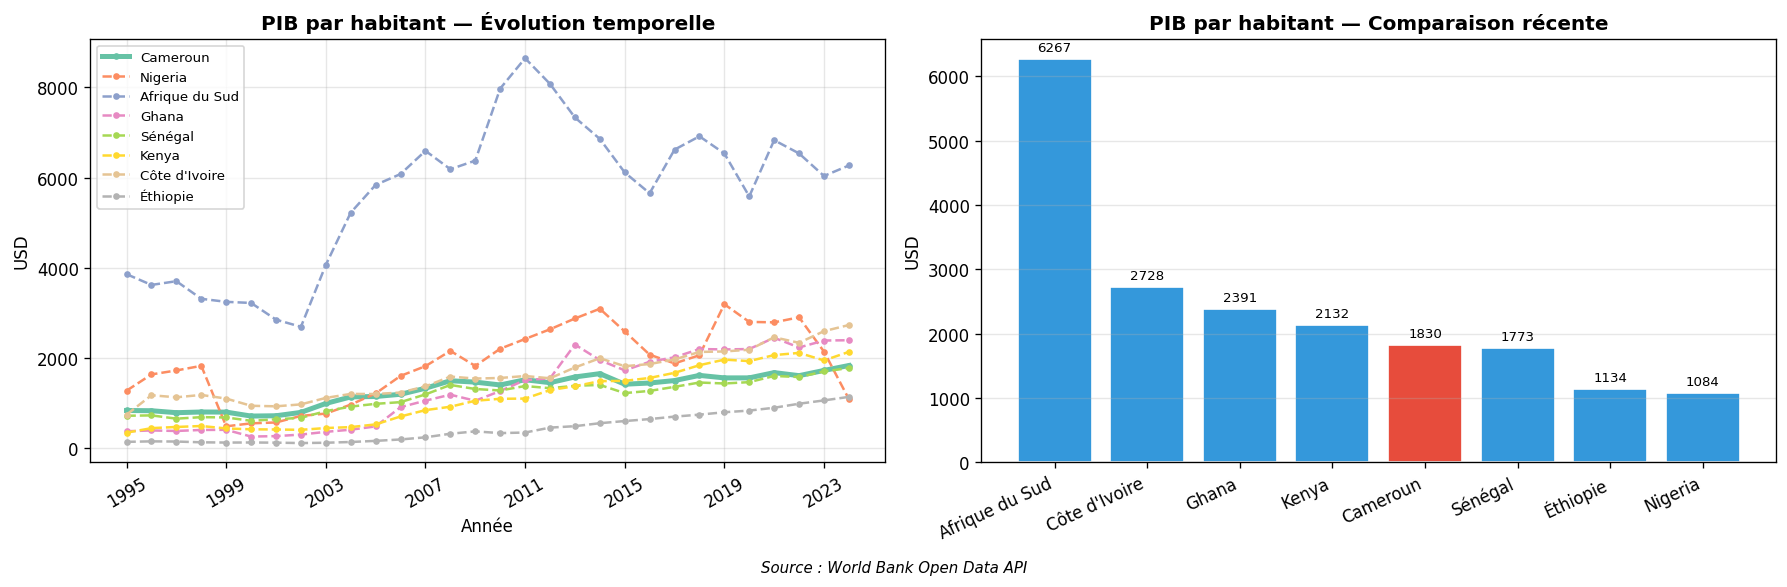


📈 Statistiques PIB par habitant (valeurs les plus récentes) :
Afrique du Sud    6267.186814
Côte d'Ivoire     2727.893522
Ghana             2390.772377
Kenya             2132.434521
Cameroun          1830.008337
Sénégal           1773.218299
Éthiopie          1133.882797
Nigeria           1084.160418


In [3]:
# ── Graphique PIB par habitant ───────────────────────────────
key = 'PIB_par_habitant_USD'
if key in datasets:
    df = datasets[key].dropna(how='all')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    colors = plt.cm.Set2.colors
    
    # Évolution temporelle
    for i, col in enumerate(df.columns):
        series = df[col].dropna()
        if series.empty:
            continue
        lw = 3 if col == 'Cameroun' else 1.5
        ls = '-' if col == 'Cameroun' else '--'
        ax1.plot(series.index, series.values, label=col,
                 color=colors[i % len(colors)], linewidth=lw, linestyle=ls, marker='o', markersize=3)
    
    ax1.set_title('PIB par habitant — Évolution temporelle', fontweight='bold')
    ax1.set_xlabel('Année')
    ax1.set_ylabel('USD')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(8, integer=True))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
    
    # Barres — valeur la plus récente
    latest = df.iloc[-1].dropna().sort_values(ascending=False)
    bar_colors = ['#e74c3c' if c == 'Cameroun' else '#3498db' for c in latest.index]
    bars = ax2.bar(latest.index, latest.values, color=bar_colors, edgecolor='white')
    ax2.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
    ax2.set_title('PIB par habitant — Comparaison récente', fontweight='bold')
    ax2.set_ylabel('USD')
    ax2.grid(axis='y', alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=25, ha='right')
    
    plt.suptitle('Source : World Bank Open Data API', fontsize=9, style='italic', y=0)
    plt.tight_layout()
    plt.show()
    
    print('\n📈 Statistiques PIB par habitant (valeurs les plus récentes) :')
    print(latest.to_string())
else:
    print('Données PIB non disponibles. Exécuter analyse.sh d abord.')

## 🏥 Section 3 — Indicateurs de Santé

### Espérance de vie et Mortalité infantile

Ces deux indicateurs sont au cœur du développement humain. L'espérance de vie reflète la qualité du système de santé, l'alimentation, et l'environnement. La mortalité infantile est particulièrement révélatrice des conditions d'accès aux soins néonataux.

**Contexte Cameroun** : Le Cameroun a connu des améliorations significatives de ces indicateurs depuis les années 1990, grâce notamment aux programmes de vaccination et à l'amélioration des infrastructures sanitaires, même si des défis importants persistent dans les zones rurales.

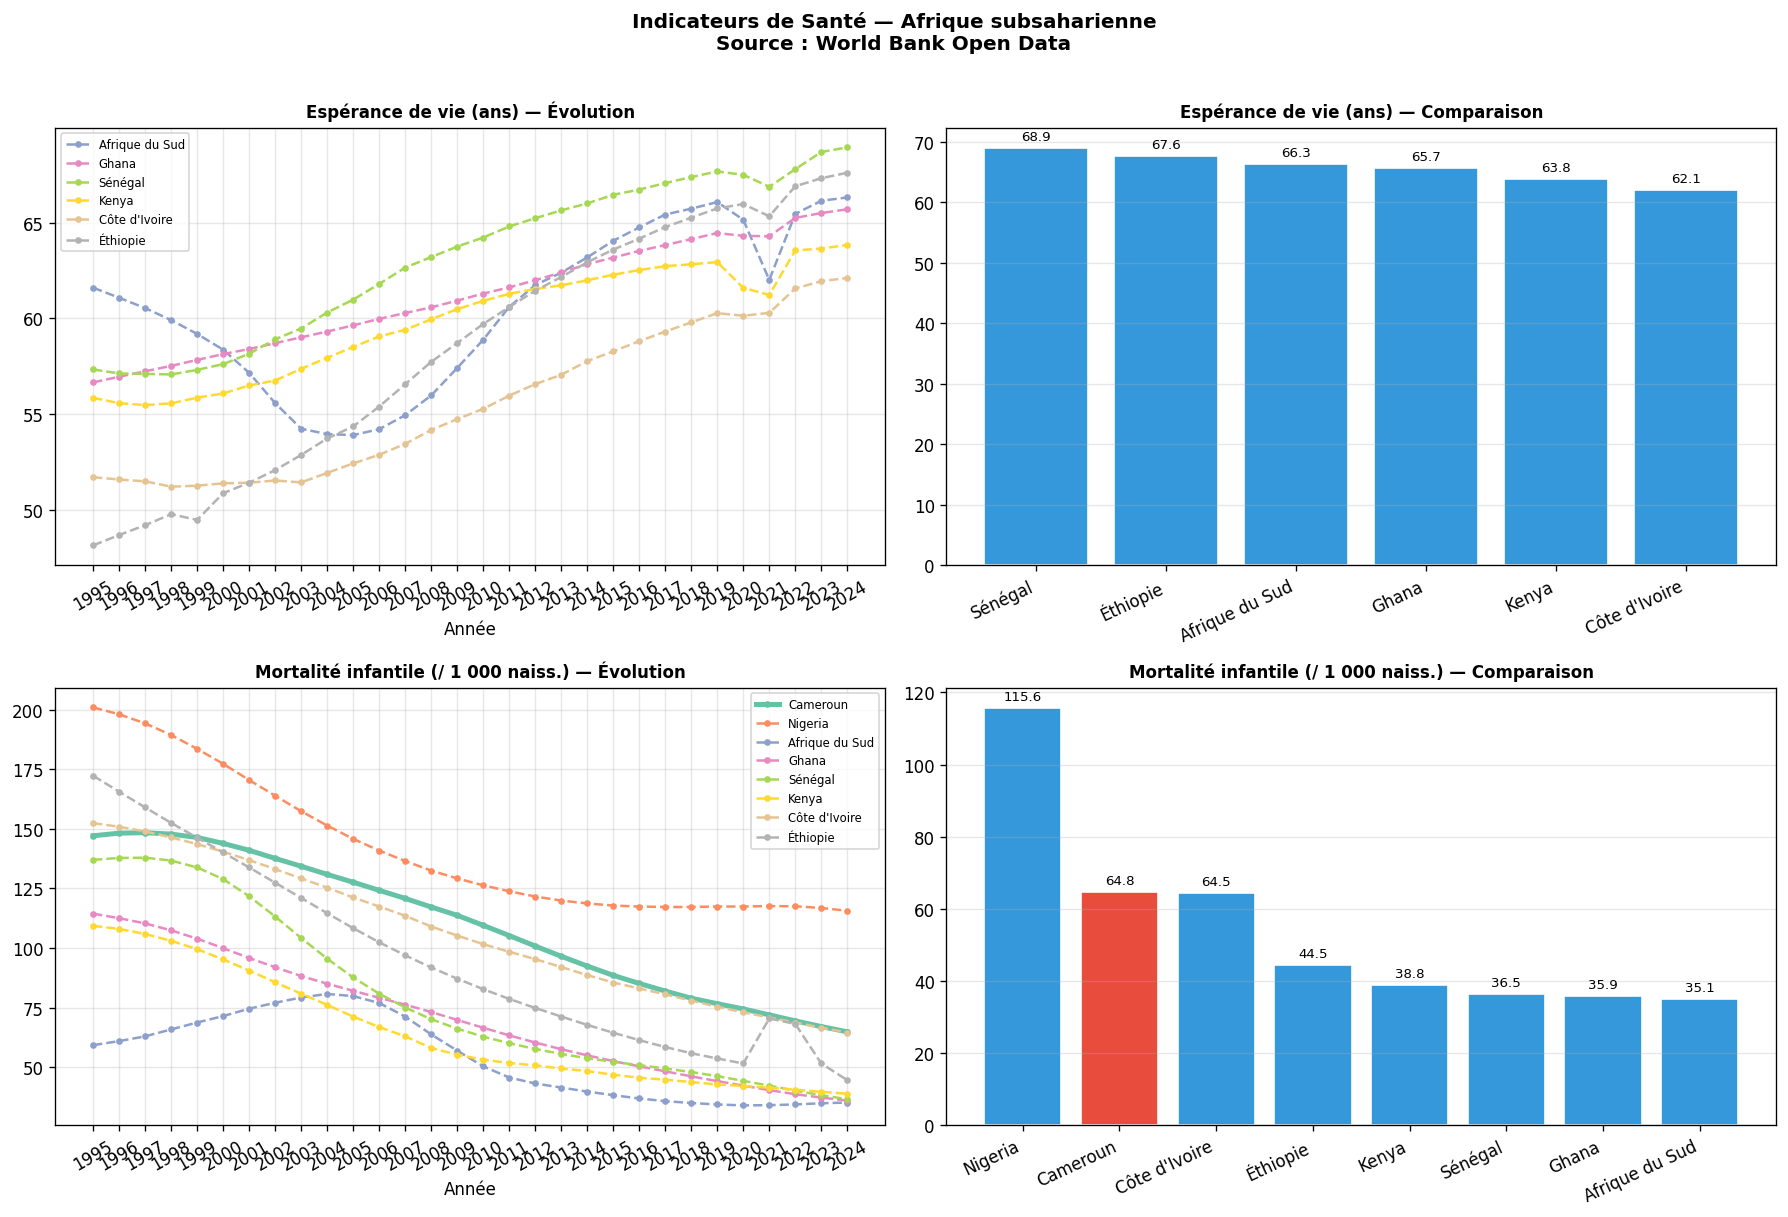

In [4]:
# ── Graphiques Santé ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
colors = plt.cm.Set2.colors

health_indicators = [
    ('Esperance_de_vie_ans',          'Espérance de vie (ans)',           axes[0, 0], axes[0, 1]),
    ('Mortalite_infantile_pour_1000', 'Mortalité infantile (/ 1 000 naiss.)', axes[1, 0], axes[1, 1]),
]

for key, title, ax_line, ax_bar in health_indicators:
    if key not in datasets:
        continue
    df = datasets[key].dropna(how='all')
    
    for i, col in enumerate(df.columns):
        series = df[col].dropna()
        if series.empty:
            continue
        lw = 3 if col == 'Cameroun' else 1.5
        ls = '-' if col == 'Cameroun' else '--'
        ax_line.plot(series.index, series.values, label=col,
                     color=colors[i % len(colors)], linewidth=lw, linestyle=ls, marker='o', markersize=3)
    
    ax_line.set_title(f'{title} — Évolution', fontweight='bold', fontsize=10)
    ax_line.set_xlabel('Année')
    ax_line.legend(fontsize=7)
    ax_line.grid(alpha=0.3)
    plt.setp(ax_line.xaxis.get_majorticklabels(), rotation=30)
    
    latest = df.iloc[-1].dropna().sort_values(ascending=False)
    bar_colors = ['#e74c3c' if c == 'Cameroun' else '#3498db' for c in latest.index]
    bars = ax_bar.bar(latest.index, latest.values, color=bar_colors, edgecolor='white')
    ax_bar.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
    ax_bar.set_title(f'{title} — Comparaison', fontweight='bold', fontsize=10)
    ax_bar.grid(axis='y', alpha=0.3)
    plt.setp(ax_bar.xaxis.get_majorticklabels(), rotation=25, ha='right')

plt.suptitle('Indicateurs de Santé — Afrique subsaharienne\nSource : World Bank Open Data',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 📚 Section 4 — Éducation et Inclusion Numérique

### Alphabétisation, Électricité et Internet

L'éducation est un pilier fondamental du développement. Le taux d'alphabétisation reflète les investissements historiques dans l'éducation de base. L'accès à l'électricité et à Internet représentent la **fracture numérique**, un enjeu majeur pour l'Afrique dans l'économie du 21e siècle.

**Contexte Cameroun** : Le Cameroun dispose d'un système éducatif bilingue (français/anglais) hérité de son histoire coloniale, avec un taux d'alphabétisation en progression. L'accès à Internet reste cependant limité, principalement concentré dans les zones urbaines comme Yaoundé et Douala.

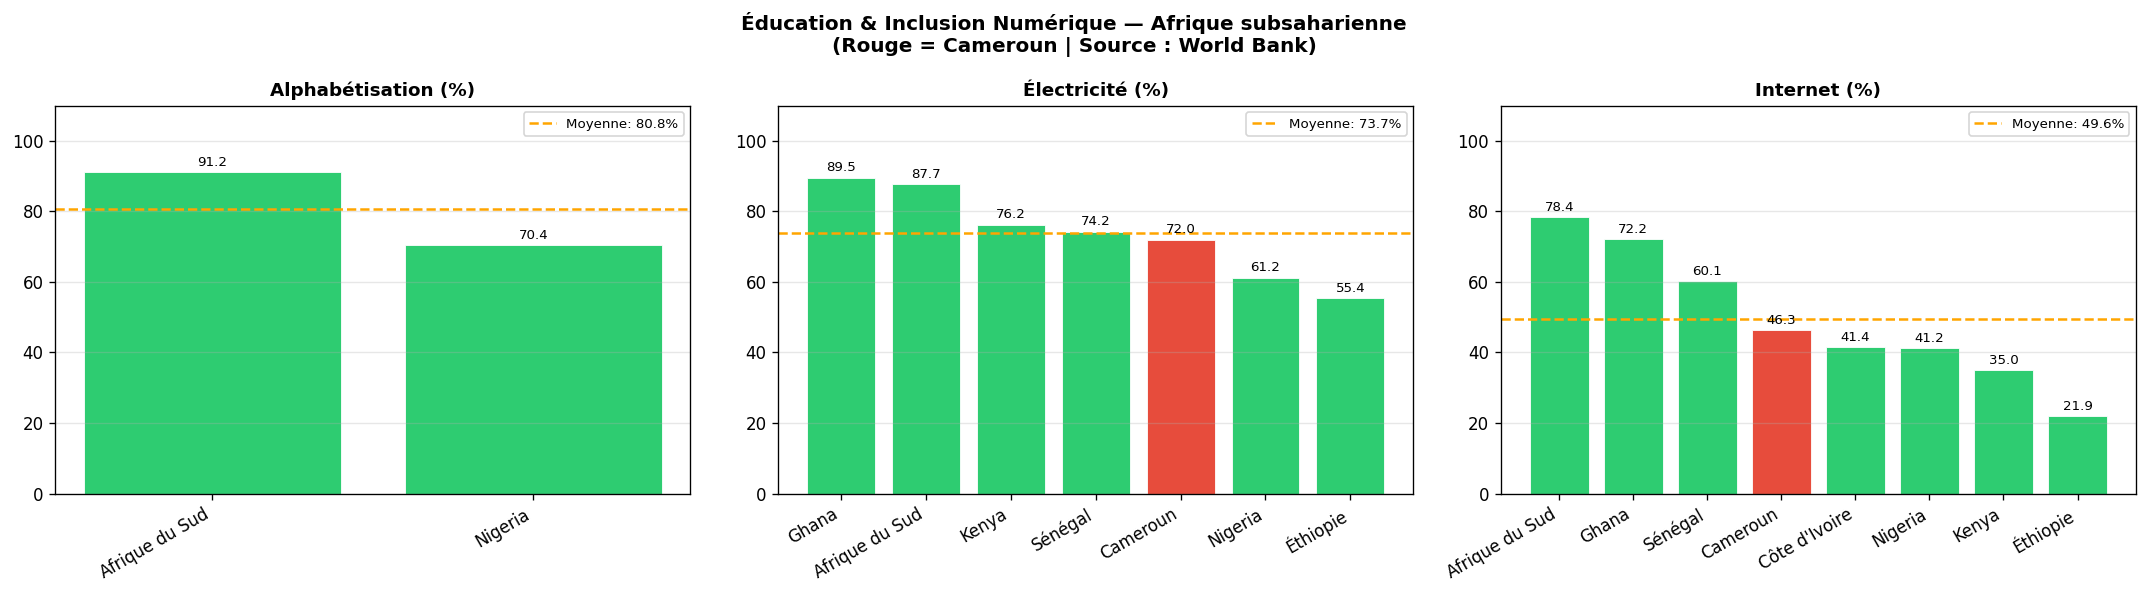

In [5]:
# ── Graphiques Éducation & Numérique ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2.colors

digital_indicators = [
    ('Taux_alphabetisation_pct', "Alphabétisation (%)",      axes[0]),
    ('Acces_electricite_pct',   "Électricité (%)",           axes[1]),
    ('Acces_internet_pct',      'Internet (%)',              axes[2]),
]

for key, title, ax in digital_indicators:
    if key not in datasets:
        ax.text(0.5, 0.5, f'Données\nnon disponibles\n({key})',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_title(title, fontweight='bold')
        continue
    
    df = datasets[key].dropna(how='all')
    latest = df.iloc[-1].dropna().sort_values(ascending=False)
    
    bar_colors = ['#e74c3c' if c == 'Cameroun' else '#2ecc71' for c in latest.index]
    bars = ax.bar(latest.index, latest.values, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylim(0, 110)
    ax.axhline(y=latest.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Moyenne: {latest.mean():.1f}%')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Éducation & Inclusion Numérique — Afrique subsaharienne\n(Rouge = Cameroun | Source : World Bank)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 🗺️ Section 5 — Tableau de bord global (Heatmap)

Cette heatmap présente **tous les indicateurs simultanément** pour tous les pays. Les couleurs représentent un score normalisé (0–100), permettant de comparer des indicateurs aux unités différentes. Les valeurs réelles sont annotées dans chaque cellule.

Cela permet d'identifier d'un coup d'œil les forces et faiblesses relatives de chaque pays.

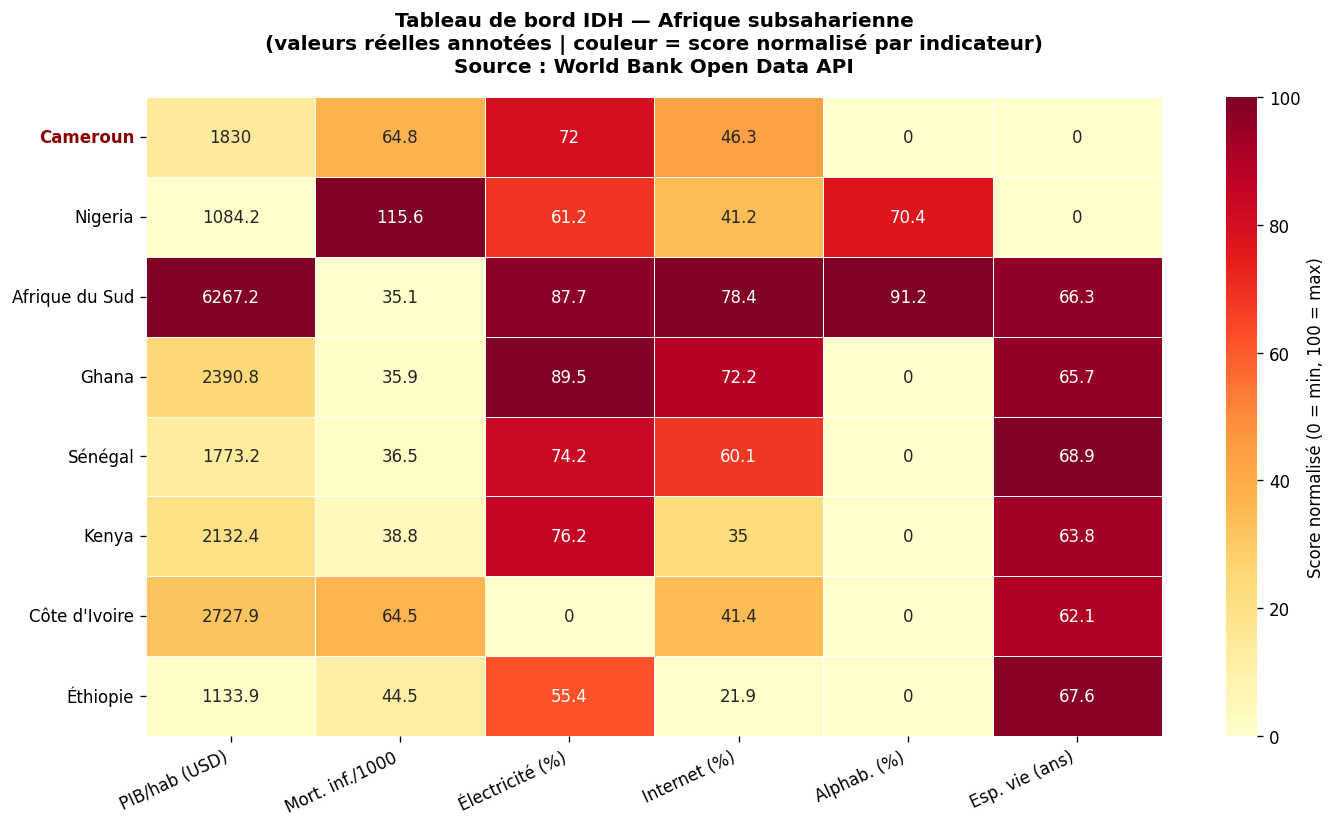


📊 Tableau des valeurs brutes :
                PIB/hab (USD)  Mort. inf./1000  Électricité (%)  Internet (%)  Alphab. (%)  Esp. vie (ans)
Cameroun               1830.0             64.8             72.0          46.3          0.0             0.0
Nigeria                1084.2            115.6             61.2          41.2         70.4             0.0
Afrique du Sud         6267.2             35.1             87.7          78.4         91.2            66.3
Ghana                  2390.8             35.9             89.5          72.2          0.0            65.7
Sénégal                1773.2             36.5             74.2          60.1          0.0            68.9
Kenya                  2132.4             38.8             76.2          35.0          0.0            63.8
Côte d'Ivoire          2727.9             64.5              0.0          41.4          0.0            62.1
Éthiopie               1133.9             44.5             55.4          21.9          0.0            67.6


In [6]:
# ── Heatmap globale ──────────────────────────────────────────
labels_fr = {
    'PIB_par_habitant_USD':          'PIB/hab (USD)',
    'Esperance_de_vie_ans':          'Esp. vie (ans)',
    'Mortalite_infantile_pour_1000': 'Mort. inf./1000',
    'Taux_alphabetisation_pct':      'Alphab. (%)',
    'Acces_electricite_pct':         'Électricité (%)',
    'Acces_internet_pct':           'Internet (%)',
}

matrix = {}
for key, label in labels_fr.items():
    if key in datasets:
        latest = datasets[key].iloc[-1].dropna()
        for country, val in latest.items():
            if country not in matrix:
                matrix[country] = {}
            matrix[country][label] = round(val, 1)

df_matrix = pd.DataFrame(matrix).T.fillna(0)

# Normalisation par colonne
df_norm = (df_matrix - df_matrix.min()) / (df_matrix.max() - df_matrix.min() + 1e-9) * 100

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(df_norm, annot=df_matrix, fmt='g', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Score normalisé (0 = min, 100 = max)'})

ax.set_title('Tableau de bord IDH — Afrique subsaharienne\n'
             '(valeurs réelles annotées | couleur = score normalisé par indicateur)\n'
             'Source : World Bank Open Data API',
             fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Mettre Cameroun en évidence
if 'Cameroun' in df_norm.index:
    cam_idx = list(df_norm.index).index('Cameroun')
    ax.get_yticklabels()[cam_idx].set_fontweight('bold')
    ax.get_yticklabels()[cam_idx].set_color('darkred')

plt.tight_layout()
plt.show()

print('\n📊 Tableau des valeurs brutes :')
print(df_matrix.to_string())

## 📝 Section 6 — Analyse et Conclusion

### Analyse des résultats

Cette section présente une analyse qualitative des données recueillies, en mettant en perspective la situation du Cameroun par rapport aux autres pays africains étudiés.

### Points clés observés :

1. **PIB par habitant** : L'Afrique du Sud et le Nigeria dominent économiquement, mais avec des inégalités importantes. Le Cameroun occupe une position intermédiaire stable.

2. **Santé** : L'espérance de vie a progressé dans presque tous les pays, signe des améliorations des systèmes de santé publique depuis les années 1990. La mortalité infantile, bien que déclinante, reste préoccupante dans certains pays.

3. **Éducation** : Le Ghana et le Kenya présentent des taux d'alphabétisation plus élevés, reflet de politiques éducatives ambitieuses. Le Cameroun progresse régulièrement.

4. **Fracture numérique** : L'accès à Internet reste le défi le plus significatif pour l'ensemble de la région. Cette réalité souligne l'urgence d'investissements dans les infrastructures numériques.

### Réflexion personnelle

En tant qu'originaire du Cameroun, ce projet m'a permis de mettre en données ce que j'observe de mon pays d'origine. Les chiffres confirment à la fois les progrès réels accomplis depuis les années 1990 et les défis qui demeurent. La fracture numérique est particulièrement parlante dans le contexte de mes études en Technologies des Systèmes Informatiques : l'accès à la formation en informatique est un levier essentiel pour le développement.

### Compétences démontrées dans ce projet

| Compétence | Implémentation |
|---|---|
| **Bash** | `scripts/analyse.sh` — orchestration, logging, virtualenv |
| **Python** | `scripts/analyse.py` — API, REGEX, CSV, graphiques |
| **PowerShell** | `scripts/analyse.ps1` — appels API Windows |
| **REGEX** | Validation codes pays, années, valeurs numériques |
| **CRON** | Mise à jour automatique quotidienne via crontab |
| **Ansible** | Déploiement automatisé sur VM Ubuntu |
| **Jupyter** | Ce rapport interactif avec visualisations |
| **GitHub** | Versionnage + CI GitHub Actions |

In [7]:
# ── Affichage du rapport texte généré automatiquement ────────
rapport_path = os.path.join(OUTPUT_DIR, 'rapport.txt')
if os.path.exists(rapport_path):
    with open(rapport_path, 'r', encoding='utf-8') as f:
        print(f.read())
else:
    print('⚠️  Rapport texte non trouvé.')
    print('   Exécuter d abord : bash scripts/analyse.sh')

  RAPPORT — ANALYSE DU DÉVELOPPEMENT HUMAIN EN AFRIQUE
  Généré le : 2026-04-11 16:41:21
  Étudiant  : Frank Laurel | ID : 300143951
  Cours     : TSI — Collège Boréal

  Pays analysés : Cameroun, Nigeria, Afrique du Sud, Ghana, Sénégal, Kenya, Côte d'Ivoire, Éthiopie
  Indicateurs   : 6
  Source        : World Bank Open Data API

─────────────────────────────────────────────────────────────────
  📊 PIB par habitant (USD)
─────────────────────────────────────────────────────────────────
   1. Afrique du Sud          6267.19 USD
   2. Côte d'Ivoire           2727.89 USD
   3. Ghana                   2390.77 USD
   4. Kenya                   2132.43 USD
   5. Cameroun                1830.01 USD ◀ FOCUS
   6. Sénégal                 1773.22 USD
   7. Éthiopie                1133.88 USD
   8. Nigeria                 1084.16 USD

  Moyenne : 2417.44 USD
  Max     : 6267.19 USD
  Min     : 1084.16 USD

─────────────────────────────────────────────────────────────────
  📊 Espérance de vie
───